In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart.csv')
print(df.shape)          # (918, 12)
print(df.dtypes)
print(df.isnull().sum())
df.head() # semua 0

(918, 12)
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


HeartDisease
1    508
0    410
Name: count, dtype: int64


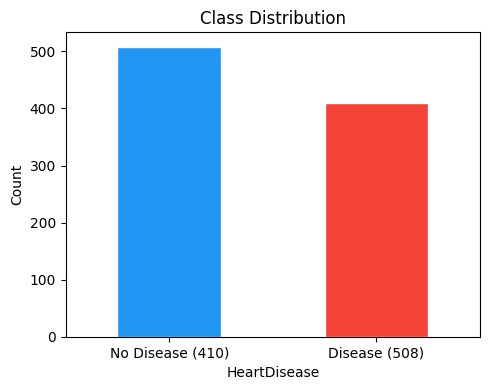

In [12]:
print(df['HeartDisease'].value_counts())
# 1: 508 (55.3%)  |  0: 410 (44.7%)  |  ratio: 0.807 → mild

fig, ax = plt.subplots(figsize=(5, 4))
df['HeartDisease'].value_counts().plot(
    kind='bar', color=['#2196F3', '#F44336'], edgecolor='white', ax=ax
)
ax.set_title('Class Distribution')
ax.set_xticklabels(['No Disease (410)', 'Disease (508)'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('eda_class_balance.png', dpi=150)
plt.show()

Cholesterol == 0 : 172 baris (18.7%)
  HeartDisease=1  : 88.4%
  HeartDisease=0  : 11.6%


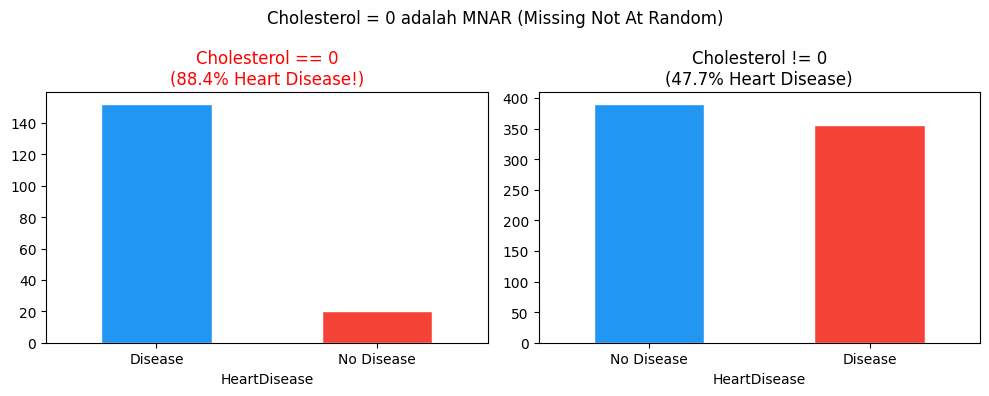

In [13]:
zero_chol    = df[df['Cholesterol'] == 0]
nonzero_chol = df[df['Cholesterol'] != 0]

print(f"Cholesterol == 0 : {len(zero_chol)} baris ({len(zero_chol)/len(df)*100:.1f}%)")
print(f"  HeartDisease=1  : {(zero_chol['HeartDisease']==1).mean()*100:.1f}%")
print(f"  HeartDisease=0  : {(zero_chol['HeartDisease']==0).mean()*100:.1f}%")
# 88.4% pasien dengan Cholesterol=0 memiliki penyakit jantung → MNAR

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
zero_chol['HeartDisease'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2196F3','#F44336'], edgecolor='white'
)
axes[0].set_title('Cholesterol == 0\n(88.4% Heart Disease!)', color='red')
axes[0].set_xticklabels(['Disease','No Disease'], rotation=0)

nonzero_chol['HeartDisease'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#2196F3','#F44336'], edgecolor='white'
)
axes[1].set_title('Cholesterol != 0\n(47.7% Heart Disease)')
axes[1].set_xticklabels(['No Disease','Disease'], rotation=0)

plt.suptitle('Cholesterol = 0 adalah MNAR (Missing Not At Random)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_cholesterol_mnar.png', dpi=150)
plt.show()

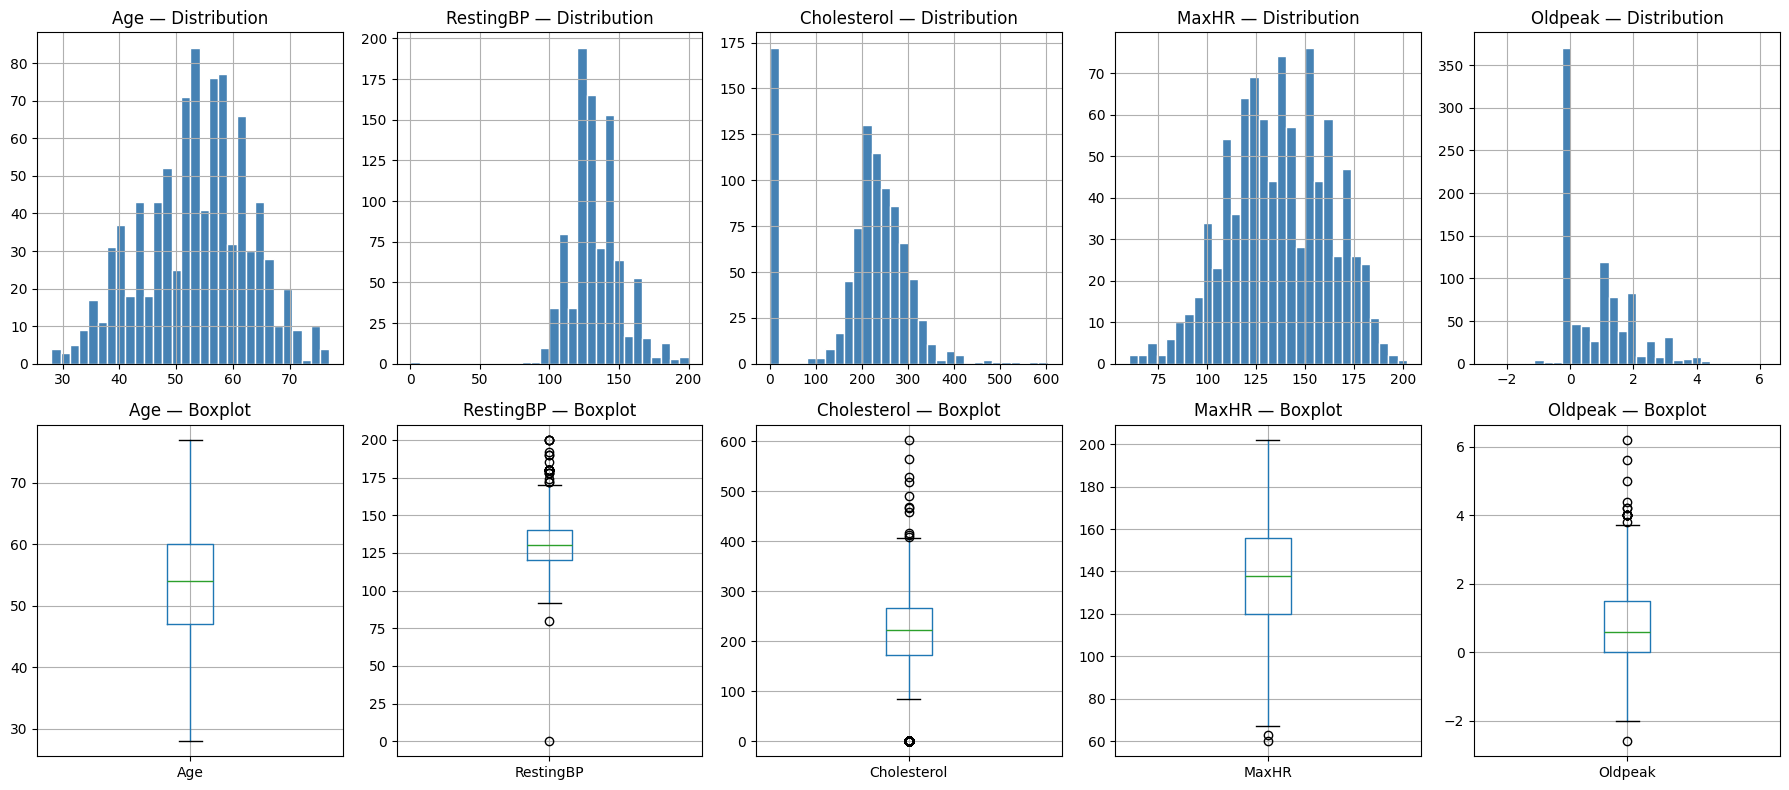

In [14]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, col in enumerate(num_cols):
    df[col].hist(ax=axes[0, i], bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} — Distribution')
    df.boxplot(column=col, ax=axes[1, i])
    axes[1, i].set_title(f'{col} — Boxplot')
plt.tight_layout()
plt.savefig('eda_numeric.png', dpi=150)
plt.show()

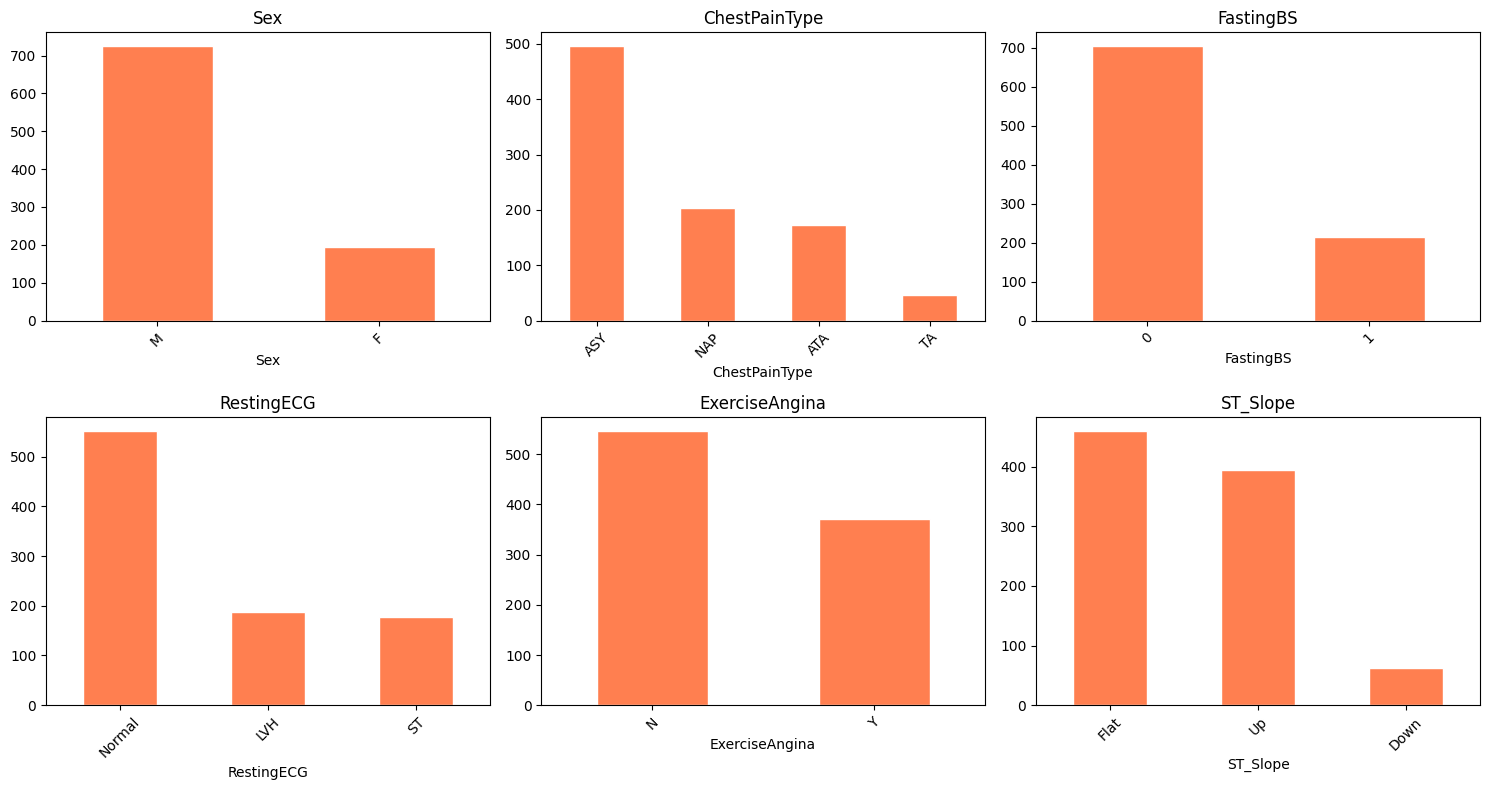

In [15]:
cat_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(cat_cols):
    ax = axes[i // 3, i % 3]
    df[col].value_counts().plot(kind='bar', ax=ax, color='coral', edgecolor='white')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150)
plt.show()

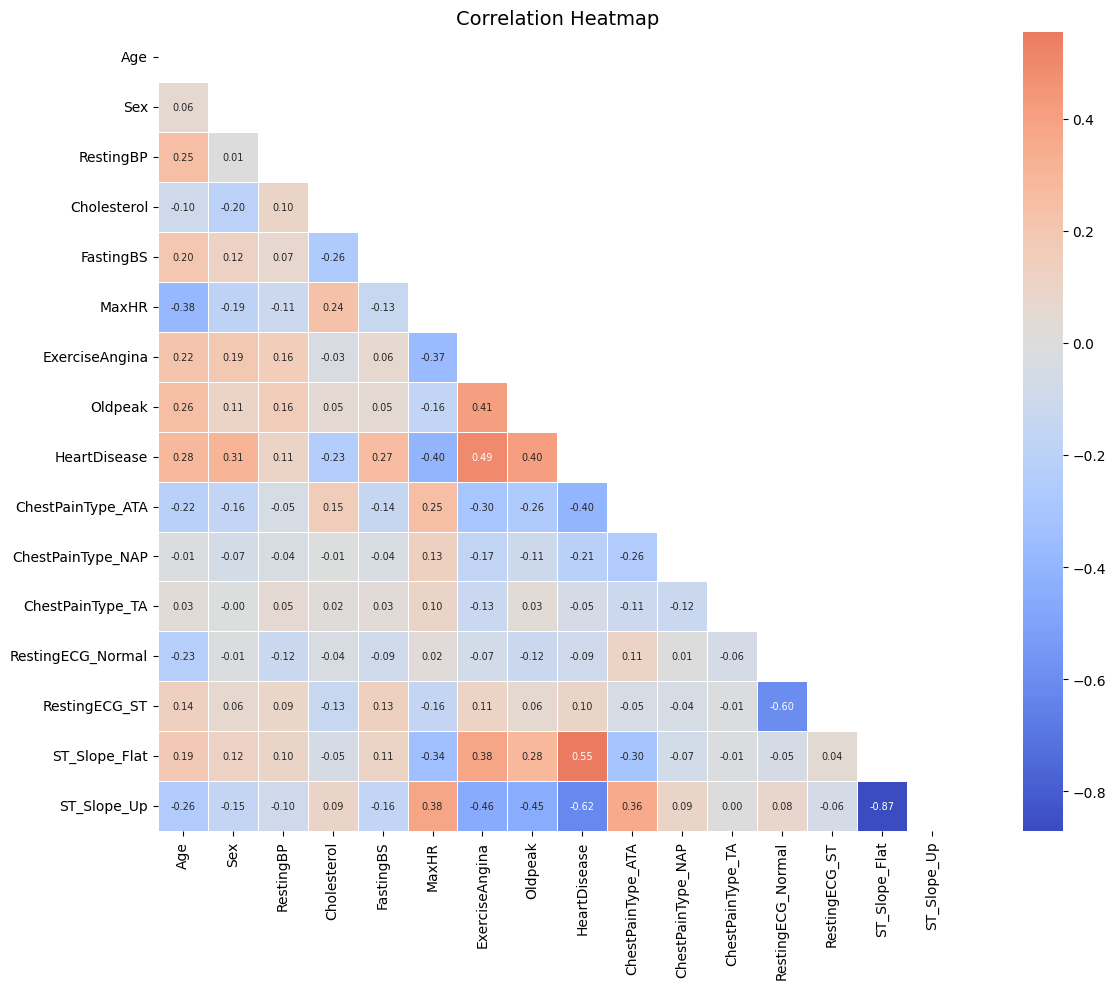

In [16]:
df_enc = df.copy()
df_enc['Sex']            = (df['Sex'] == 'M').astype(int)
df_enc['ExerciseAngina'] = (df['ExerciseAngina'] == 'Y').astype(int)
df_enc = pd.get_dummies(df_enc, columns=['ChestPainType','RestingECG','ST_Slope'], drop_first=True)

plt.figure(figsize=(14, 10))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150)
plt.show()